## <font color='##3B9C9C'>Projeto #2: Análise dos dados de customer churn do banco na Bélgica</font>
_______________________________________________________________________________________________

As análises que você fez até aqui para as sedes do banco na França, Espanha, Alemanha e Portugal ficaram muito boas. A forma como você comunicou os resultados de forma objetiva e fácil para os demais colaboradores não-técnicos do banco entenderem, bem como o nível de detalhes que você adicionou no material final despertaram o **interesse do time de CRM da Bélgica em entender o perfil dos clientes que estão deixando de utilizar os serviços do banco no país**.

Assim como você incorporou os dados de Portugal na análise anterior, você precisará adicionar os dados de *customer churn* da Bélgica (**`.dados/Customer-Churn-Records-Belgium.csv`**) e considerar os dados de cidades dos clientes do país (**`./dados/Customer-Counties-Belgium.csv`**). A adição dos gráficos em uma apresentação é opcional, no entanto, você deverá plotar os gráficos e sumarizar os dados de rotatividade considerando todos os 5 países juntos, assim como foi feito na etapa anterior com os quatro países.

A equipe do banco na Bélgica precisa da sua ajuda para responder as seguintes perguntas de negócio:

##### Como está a taxa de rotatividade média da Bélgica comparada aos demais países?
##### Qual o perfil dos clientes belgas que estão deixando de utilizar os serviços do banco?
<br/><br/>

🛠️ **Assistência nas análises**

Você pode escolher o nível de assistência em que se sinta mais confortável entre os 3 disponíveis durante a execução da sua análise:

1. **Nível 1**: Notebook contendo as requisições do que deve ser feito, com a maior parte do código já estruturada, mas **faltando algumas partes chaves para preenchimento**, como nomes de funções, argumentos, etc.
3. **Nível 2**: Notebook contendo o passo a passo de como poder ser feito, mas **faltando as linhas de códigos**.
5. **Nível 3**: Notebook contendo somente com as perguntas de negócio, mas **sem nenhum código ou passo a passo de como pode ser feito**.

Lembre-se! O sucesso do seu aprendizado não está no nível em que você realizará as análises, mas no que você agora é capaz de desenvolver e não era antes de iniciar esse curso.

⚠️ **Lembretes Importantes!**
- Ao juntar os dados da Bélgica, lembre-se de utilizar como base o arquivo final em csv que você gerou com os quatro países (**`./dados/Customer-Churn-Records_FR-GE-ES-PT.csv`**), já incluindo Portugal.

💻 **Datasets a serem utilizados**
- **`.dados/Customer-Churn-Records-Belgium.csv`**
- **`./dados/Customer-Counties-Belgium.csv`**
- **`./dados/Customer-Churn-Records_FR-GE-ES-PT.csv`**

✅ **Durante a execução das análises, responda as seguintes perguntas:**

1. Qual variável tem a maior correlação com a variável Exited?
2. Quais as 3 cidades com as maiores taxas de rotatividade?
3. Qual a taxa de rotatividade do banco na Bélgica e quanto a mais isso representa em relação a Portugal?
4. O grupo de clientes com idades entre 35-45 anos é o mais representativo com um total de ( ) clientes. No entanto, o grupo com maior taxa de rotatividade é o grupo de clientes com menos de 35 anos cuja taxa de rotatividade é de ( )%.
5. Qual a diferença de salário estimado entre os clientes que saíram e permaneceram no banco da Bélgica?


**Bom trabalho!**

#### Importa os datasets e concatena

In [1]:
# PASSO A PASSO:
# Este bloco executa uma etapa específica da análise.
# Leia os comentários e entenda o objetivo antes de rodar.

## Importa dependências
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importa os dados

### TO DO: Leia o dataframe principal com os clientes da França, Alemanha, Portugal e Espanha
df_almost_full = pd.read_csv('Customer-Churn-Records_FR-GE-PT-ES.csv')

### TO DO: Leia o novo dataframe com os dados dos clientes da Bélgica
df_belgium = pd.read_csv('Customer-Churn-Records-Belgium.csv')

### TO DO: Leia o novo dataframe com as cidades dos clientes da Bélgica
df_belgium_cities = pd.read_csv('Customer-Counties-Belgium.csv')


In [2]:
df_belgium.shape

(884, 18)

In [3]:
df_belgium.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

In [4]:
df_belgium_cities.shape

(883, 3)

In [5]:
df_belgium_cities.columns

Index(['CustomerId', 'Geography', 'County'], dtype='object')

In [6]:
#df_belgium = df_belgium.drop(['RowNumber','Surname'], axis=1) ou  df_belgium.drop(columns = ['RowNumber','Surname'])
df_belgium.shape

(884, 18)

In [7]:
df_belgium = df_belgium.drop_duplicates()

In [8]:
df_belgium = df_belgium.dropna()
df_belgium.shape

(884, 18)

In [9]:
df_belgium_cities = df_belgium_cities.drop_duplicates()
df_belgium_cities = df_belgium_cities.dropna()

In [10]:
df_belgium_cities.shape

(883, 3)

In [11]:
### TO DO: Faça o merge do dataframe de cidades no dataframe dos clientes da Bélgica 
df_belgium_full = pd.merge(df_belgium, df_belgium_cities, on='CustomerId', how='left')
df_belgium_full.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography_x,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Geography_y,County
0,1813,18769397,Obiajulu,545,Belgium,Female,33,3,191150.312178,1,False,False,67925.669111,True,False,0,GOLD,488.030278,Belgium,Liège
1,-1495,18659339,Welch,621,Belgium,Female,29,3,168518.331692,1,True,False,47403.875845,True,False,3,SILVER,518.103104,Belgium,Brussels
2,5362,18612046,Lettiere,606,Belgium,Male,47,6,103315.853394,1,True,False,51596.327861,True,False,5,DIAMOND,498.331838,Belgium,Brussels


In [12]:
df_almost_full.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned', 'County'],
      dtype='object')

In [13]:
df_belgium_full.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography_x',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned', 'Geography_y',
       'County'],
      dtype='object')

In [14]:
df_belgium_full = df_belgium_full.drop(columns='Geography_y')
df_belgium_full = df_belgium_full.rename({'Geography_x': 'Geography'},axis=1)
df_almost_full = df_almost_full.drop(columns='Surname')

In [15]:
df_belgium_full.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned', 'County'],
      dtype='object')

In [16]:
df_almost_full.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned', 'County'],
      dtype='object')

In [17]:
df_belgium_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884 entries, 0 to 883
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           884 non-null    int64  
 1   CustomerId          884 non-null    int64  
 2   Surname             884 non-null    object 
 3   CreditScore         884 non-null    int64  
 4   Geography           884 non-null    object 
 5   Gender              884 non-null    object 
 6   Age                 884 non-null    int64  
 7   Tenure              884 non-null    int64  
 8   Balance             884 non-null    float64
 9   NumOfProducts       884 non-null    int64  
 10  HasCrCard           884 non-null    bool   
 11  IsActiveMember      884 non-null    bool   
 12  EstimatedSalary     884 non-null    float64
 13  Exited              884 non-null    bool   
 14  Complain            884 non-null    bool   
 15  Satisfaction Score  884 non-null    int64  
 16  Card Typ

In [18]:
### TO DO: Remova a coluna RowNumber


In [19]:
### TO DO: Visualize as 5 primeiras linhas do dataframe da Bélgica


In [20]:
### TO DO: Certifique-se de que não tem nenhum cliente sem dados de cidade


In [21]:
### TO DO: Certifique-se de que os dataframes de clientes da Bélgica 
### e demais países têm as mesmas colunas


In [22]:
df_belgium_full.shape

(884, 19)

In [23]:
df_almost_full.shape

(10568, 17)

In [24]:
### TO DO: Concatene os dois dataframes (Bélgica e demais países)
df_main = pd.concat([df_almost_full, df_belgium_full])
df_main.head(3)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,County,RowNumber,Surname
0,15737173,474.637955,Spain,Male,38,3,68990.682014,2,True,False,42856.316169,True,False,3,GOLD,578.682607,Madrid,NaN,NaN
1,15597945,522.650461,Spain,Female,37,8,55484.615047,2,True,False,41939.810698,True,False,2,DIAMOND,590.088891,Bilbao,NaN,NaN
2,15625047,550.825497,France,Female,37,5,55645.820270,1,True,True,37326.078597,True,False,3,PLATINUM,682.831504,Toulouse,NaN,NaN


In [25]:
df_main.shape

(11452, 19)

In [26]:
### TO DO: Visualize os valores únicos na coluna Geography 
### para garantir que os dados da Bélgica foram adicionados
df_main['Geography'].unique()

array(['Spain', 'France', 'Germany', 'Portugal', 'Belgium'], dtype=object)

In [27]:
df_main.head(3)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,County,RowNumber,Surname
0,15737173,474.637955,Spain,Male,38,3,68990.682014,2,True,False,42856.316169,True,False,3,GOLD,578.682607,Madrid,NaN,NaN
1,15597945,522.650461,Spain,Female,37,8,55484.615047,2,True,False,41939.810698,True,False,2,DIAMOND,590.088891,Bilbao,NaN,NaN
2,15625047,550.825497,France,Female,37,5,55645.820270,1,True,True,37326.078597,True,False,3,PLATINUM,682.831504,Toulouse,NaN,NaN


#### Gere um heatmap com a matriz de correlação entre as variáveis numéricas considerando somente a Bélgica

Sugestões - você pode:
- utilizar as funções query ou loc para filtrar o dataframe
- gerar um gráfico de correlação entre as variáveis
- usar o parâmetro de anotação com a correlação entre as variáveis

In [28]:
### TO DO: Crie um novo dataframe somente com os clientes da Bélgica 
df_main_belgium = df_main.query('Geography == "Belgium"')
df_main_belgium.head(3)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,County,RowNumber,Surname
0,18769397,545.0,Belgium,Female,33,3,191150.312178,1,False,False,67925.669111,True,False,0,GOLD,488.030278,Liège,1813.0,Obiajulu
1,18659339,621.0,Belgium,Female,29,3,168518.331692,1,True,False,47403.875845,True,False,3,SILVER,518.103104,Brussels,-1495.0,Welch
2,18612046,606.0,Belgium,Male,47,6,103315.853394,1,True,False,51596.327861,True,False,5,DIAMOND,498.331838,Brussels,5362.0,Lettiere


In [29]:
df_main_belgium.info()

<class 'pandas.core.frame.DataFrame'>
Index: 884 entries, 0 to 883
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerId          884 non-null    int64  
 1   CreditScore         884 non-null    float64
 2   Geography           884 non-null    object 
 3   Gender              884 non-null    object 
 4   Age                 884 non-null    int64  
 5   Tenure              884 non-null    int64  
 6   Balance             884 non-null    float64
 7   NumOfProducts       884 non-null    int64  
 8   HasCrCard           884 non-null    bool   
 9   IsActiveMember      884 non-null    bool   
 10  EstimatedSalary     884 non-null    float64
 11  Exited              884 non-null    bool   
 12  Complain            884 non-null    bool   
 13  Satisfaction Score  884 non-null    int64  
 14  Card Type           884 non-null    object 
 15  Point Earned        884 non-null    float64
 16  County       

In [30]:
df_main_belgium = df_main_belgium.drop(columns=['RowNumber', 'Surname'])
df_main_belgium.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned', 'County'],
      dtype='object')

In [31]:
df_main_belgium = df_main_belgium.select_dtypes(include=['number', 'bool'])
df_main_belgium.head(3)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
0,18769397,545.0,33,3,191150.312178,1,False,False,67925.669111,True,False,0,488.030278
1,18659339,621.0,29,3,168518.331692,1,True,False,47403.875845,True,False,3,518.103104
2,18612046,606.0,47,6,103315.853394,1,True,False,51596.327861,True,False,5,498.331838


In [32]:
### TO DO: Crie um novo dataframe contendo somente essas colunas definidas anteriormente


In [33]:
### TO DO: Arredonde todos os valores para 2 casas decimais
df_main_belgium = df_main_belgium.round(2)
df_main_belgium.head(3)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
0,18769397,545.0,33,3,191150.31,1,False,False,67925.67,True,False,0,488.03
1,18659339,621.0,29,3,168518.33,1,True,False,47403.88,True,False,3,518.10
2,18612046,606.0,47,6,103315.85,1,True,False,51596.33,True,False,5,498.33


In [34]:
### TO DO: Crie uma matriz de correlação a partir desse dataframe criado
matrix_df_main_belgium_corr = df_main_belgium.corr()
matrix_df_main_belgium_corr

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
CustomerId,1.000000,0.044955,0.025107,0.001311,-0.001895,0.035476,-0.008422,0.001749,-0.012281,-0.002358,-0.060243,0.023480,-0.013766
CreditScore,0.044955,1.000000,-0.400928,-0.020418,-0.002757,0.012572,0.003830,0.016805,0.470061,0.748502,0.005522,-0.040067,0.010705
Age,0.025107,-0.400928,1.000000,0.006322,-0.043725,0.010076,-0.023560,-0.035020,-0.316094,-0.511279,0.008351,-0.004405,0.020533
Tenure,0.001311,-0.020418,0.006322,1.000000,-0.025589,-0.021472,-0.050748,-0.027478,0.041054,-0.032499,-0.003437,-0.001316,0.028380
Balance,-0.001895,-0.002757,-0.043725,-0.025589,1.000000,0.023430,-0.033477,-0.028924,0.050112,0.023845,-0.071749,-0.019631,-0.264037
NumOfProducts,0.035476,0.012572,0.010076,-0.021472,0.023430,1.000000,0.074556,-0.007039,-0.015102,-0.024490,-0.024101,0.039253,-0.018312
HasCrCard,-0.008422,0.003830,-0.023560,-0.050748,-0.033477,0.074556,1.000000,-0.039316,0.058684,0.043519,-0.017199,-0.037140,0.010363
IsActiveMember,0.001749,0.016805,-0.035020,-0.027478,-0.028924,-0.007039,-0.039316,1.000000,-0.039550,-0.002293,-0.157262,-0.013295,0.032208
EstimatedSalary,-0.012281,0.470061,-0.316094,0.041054,0.050112,-0.015102,0.058684,-0.039550,1.000000,0.630954,0.065104,-0.021829,0.009287
Exited,-0.002358,0.748502,-0.511279,-0.032499,0.023845,-0.024490,0.043519,-0.002293,0.630954,1.000000,0.004343,-0.011581,-0.001606


In [35]:
### TO DO: Crie uma matriz de máscara superior
mask = np.triu(np.ones(matrix_df_main_belgium_corr.shape)).astype(bool)
corr_filtrada = matrix_df_main_belgium_corr.where(~mask)
corr_filtrada

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
CustomerId,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,0.044955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,0.025107,-0.400928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,0.001311,-0.020418,0.006322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Balance,-0.001895,-0.002757,-0.043725,-0.025589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumOfProducts,0.035476,0.012572,0.010076,-0.021472,0.023430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasCrCard,-0.008422,0.003830,-0.023560,-0.050748,-0.033477,0.074556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IsActiveMember,0.001749,0.016805,-0.035020,-0.027478,-0.028924,-0.007039,-0.039316,NaN,NaN,NaN,NaN,NaN,NaN
EstimatedSalary,-0.012281,0.470061,-0.316094,0.041054,0.050112,-0.015102,0.058684,-0.039550,NaN,NaN,NaN,NaN,NaN
Exited,-0.002358,0.748502,-0.511279,-0.032499,0.023845,-0.024490,0.043519,-0.002293,0.630954,NaN,NaN,NaN,NaN


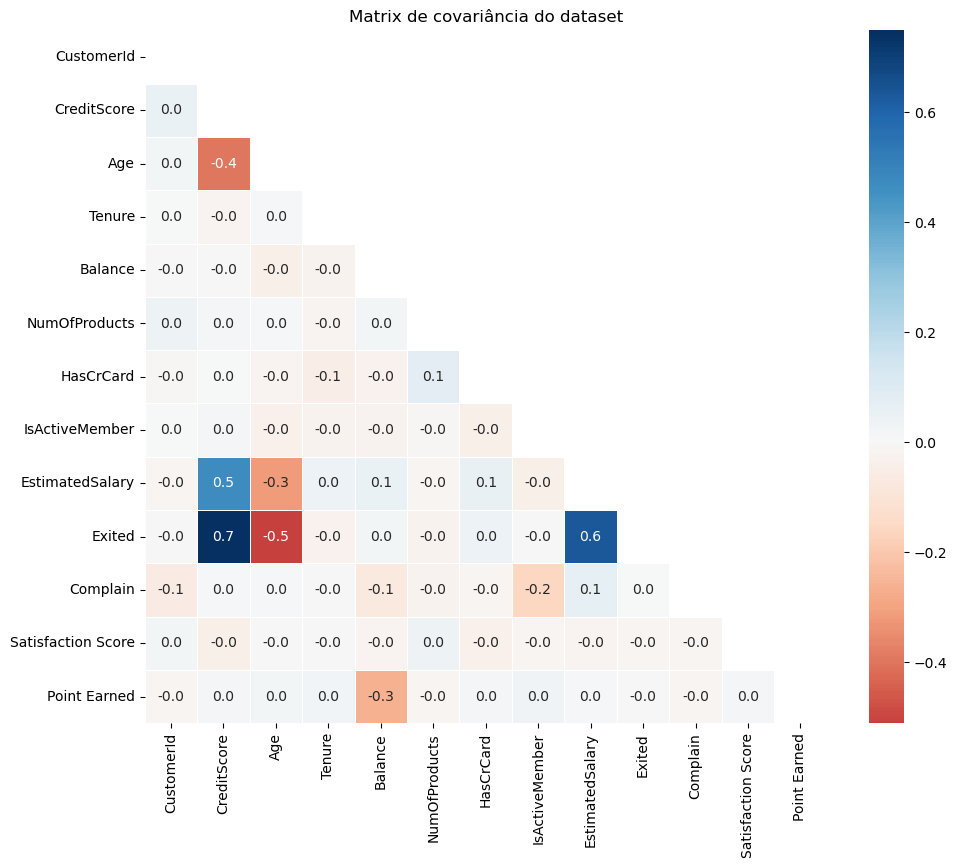

In [36]:

# Cria o gradiente de cores para o gráfico
cmap = sns.diverging_palette(20, 230, as_cmap=True)

# Cria o objeto da figura com tamanho específico
f, ax = plt.subplots(figsize=(11, 9))

### TO DO: Crie o heatmap a partir da matriz de correlação
sns.heatmap(corr_filtrada, annot=True, fmt='.1f', cmap='RdBu', center=0, linewidths=0.5)

### TO DO: Adicione um título para o gráfico
plt.title('Matrix de covariância do dataset')
### TO DO: Plote o gráfico
plt.show()


##### <font color='#E41B17'>❓ Pergunta: </font> Qual variável tem a maior correlação com a variável Exited?<font color='#52595D'>

##### <font color='blue'> Resposta: </font> CreditScore

#### Quais são as 3 cidades com maior taxa de rotatividade e o percentual de cada?
- Plote um gráfico com a rotatividade média entre cidades
- Crie uma tabela agrupada com a média da rotatividade entre cidades

In [ ]:
df_main_belgium_group = df_main.query('Geography == "Belgium"')
df_main_belgium_group.drop(columns=[['RowNumber', 'Surname']])
df_main_belgium_group.head(3)

In [39]:
### TO DO: Utilize o mesmo racional para criar um dataframe com o 
### total de clientes e rotatividade média agrupados por país e cidade
df_main_group = df_main.groupby(by=['Geography','County'])['Exited'].mean()

In [43]:
### TO DO: Visualize esse dataframe criado
df_main_group = df_main_group.sort_values(by=['Exited'], ascending=False).reset_index()
df_main_group

,index,Geography,County,Exited
0,16,Portugal,Braga,0.266055
1,4,Belgium,Leuven,0.265734
2,2,Belgium,Brussels,0.265306
3,3,Belgium,Ghent,0.257353
4,0,Belgium,Antwerp,0.254902
5,5,Belgium,Liège,0.254777
6,23,Spain,Madrid,0.233607
7,11,Germany,Berlin,0.219178
8,15,Germany,Munich,0.210412
9,17,Portugal,Coimbra,0.209524


[Text(0.5, 0, 'taxa de rotatividade'), Text(0, 0.5, 'Países')]

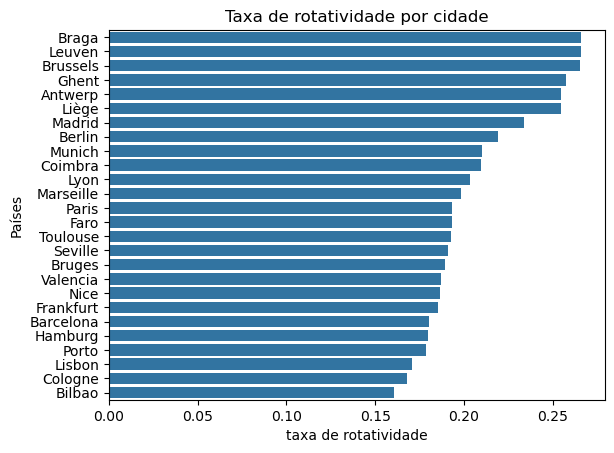

In [44]:
### TO DO: Crie um gráfico de barras horizontal utilizando o dataframe criado. No eixo y são os países e no eixo x a taxa de rotatividade
fig = sns.barplot(data=df_main_group, x='Exited', y='County')
fig.set_title('Taxa de rotatividade por cidade')
fig.set(xlabel='taxa de rotatividade', ylabel='Países')

##### <font color='#E41B17'>❓ Pergunta: </font> Quais as 3 cidades com as maiores taxas de rotatividade?<font color='#52595D'>

##### <font color='blue'> Resposta: </font> 

#### Qual a taxa de rotatividade média na Bélgica?
- Plote um gráfico com a rotatividade média entre países
- Crie uma tabela agrupada com a média da rotatividade entre países

In [ ]:
### TO DO: A partir do dataframe com todos os países, crie um dataframe com o 
### total de clientes e rotatividade média agrupados por país


In [ ]:
### TO DO: Visualize esse dataframe criado


In [ ]:
### TO DO: Crie um gráfico de barras utilizando o dataframe criado. No eixo x são os países e no eixo y a taxa de rotatividade


##### <font color='#E41B17'>❓ Pergunta: </font> Qual a taxa de rotatividade do banco na Bélgica e quanto a mais isso representa em relação a Portugal?<font color='#52595D'>

##### <font color='blue'> Resposta: </font>

#### Qual grupo de idade (<35 anos, 35 - 45 anos, 45 - 55 anos, >55 anos) tem o maior número de clientes? E qual grupo tem a maior taxa de rotatividade?
- Crie um gráfico de barras, linhas ou outro de sua preferência para visualizar os dados e sumarize os dados para obter os valores das médias.

In [ ]:
### TO DO: Crie uma variável categórica com os seguintes grupos de idade: '<35', '35-45', '45-55', '>55'.


In [ ]:
### TO DO: Crie um dataframe com o total de saídas do banco

In [ ]:
### TO DO: Crie um dataframe com o total de clientes, saídas e taxa de rotatividade média do banco por grupo de idade. 


In [ ]:
### TO DO: Visualize o dataframe criado anteriormente


In [ ]:
### TO DO: Crie um gráfico de barras com o total de clientes (eixo y) por grupo de idade (eixo x)


In [ ]:
### TO DO: Crie um gráfico de barras com a taxa de rotatividade média (eixo y) por grupo de idade (eixo x)


##### <font color='#E41B17'>❓ Pergunta: <font color='#52595D'>Preencha os dados faltantes nessa afirmação (Número inteiro sem casas decimais):
O grupo de clientes com idades entre 35-45 anos é o mais representativo com um total de __(   )__ clientes. No entanto, o grupo com maior taxa de rotatividade é o grupo de clientes com menos de 35 anos cuja taxa de rotatividade é de __(  )__%.

##### <font color='blue'> Resposta: </font> 

#### Qual a diferença da média salarial entre quem saiu e permaneceu no banco da Bélgica

- Crie um gráfico boxplot ou gráfico de distribuição
- Crie uma tabela agrupada com médias dos dois grupos

In [ ]:
### TO DO: Crie um gráfico boxplot do Salário Estimado entre os 
### grupos de clientes que saíram e permaneceram no banco da Bélgica

In [ ]:
### TO DO: Crie um dataframe com a média do salário estimado 
### entre os grupos de quem permaneceu e saiu do banco da Bélgica


In [ ]:
### TO DO: Visualize o dataframe criado


##### <font color='#E41B17'>❓ Pergunta: <font color='#52595D'> Qual a diferença de salário estimado entre os clientes que saíram e permaneceram no banco da Bélgica?

##### <font color='blue'> Resposta: </font>